# 03 · O juiz responde certo?

O [notebook 02](02_comparar_busca.ipynb) mediu só a **busca** (a fonte certa aparece entre os primeiros resultados?). Aqui medimos o **produto final**: a resposta que o usuário lê, depois que o LLM junta as fontes.

**Como foi feito.** As 45 perguntas do [gabarito](../avaliacao/gabarito.yaml) passaram pelo juiz com `python -m juiz.avaliar_respostas`, e cada resposta foi medida de três jeitos:

| Tipo | Métrica | O que mede |
|---|---|---|
| automática | **acertou_se_respondia** | respondeu quando o gabarito tem resposta; disse "não encontrei" quando não tem |
| automática | **conclusao_certa** | a 1ª palavra (Sim / Não / Depende) bate com a do gabarito |
| automática | **citou_fonte_certa** | citou uma das fontes ou regras esperadas |
| automática | **citações inventadas** | citou uma regra que não existe no CRD, ou uma fonte [F7] que não foi entregue |
| avaliador LLM | **nota** | outro LLM compara com a resposta esperada: correta / parcial / incorreta |
| humano | **revisão às cegas** | 12 respostas lidas por uma pessoa, sem ver a nota do avaliador |

As métricas automáticas são **objetivas** (não dependem de opinião), mas só olham a superfície. O avaliador LLM lê o conteúdo, mas pode errar; a revisão humana serve pra medir **o quanto dá pra confiar nele**.

> **Configuração desta rodada:** busca **e5-small** (a reserva local) + **Gemini 3.5 Flash-Lite** (a reserva mais fraca), porque a cota grátis do dia dos modelos principais tinha acabado. Ou seja, isto mede o **piso** do juiz: a qualidade quando tudo cai pra reserva.
>
> **Duas rodadas:** as seções 1 a 6 analisam a **rodada 1**, que serviu de diagnóstico. A seção 7 mostra os ajustes feitos a partir dele e a **rodada 2**.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from juiz import config
from juiz.avaliar_respostas import (NOTAS, carregar_gabarito, concordancia, conclusao_confere,
                                     conclusao_da_resposta, kappa_de_cohen)

ROTULO = "flash-lite_e5"  # rodada 1, antes dos ajustes: avaliacao/resultados/respostas_flash-lite_e5.jsonl
gabarito = {q["id"]: q for q in carregar_gabarito()}
df = pd.read_json(config.RESULTADOS_DIR / f"respostas_{ROTULO}.jsonl", lines=True)
# A conclusão é recalculada com o gabarito atual (algumas esperadas aceitam mais de uma resposta).
df["conclusao_esperada"] = [gabarito[i].get("conclusao") for i in df.id]
df["conclusao_da_resposta"] = df.resposta.map(conclusao_da_resposta)
df["conclusao_certa"] = [conclusao_confere(gabarito[i].get("conclusao"), c) for i, c in zip(df.id, df.conclusao_da_resposta)]
df["citacao_inventada"] = (df.regras_inventadas.str.len() + df.fontes_inexistentes.str.len()) > 0
print(f"{len(df)} respostas · busca {df.busca.unique().tolist()} · LLM {df.modelo_que_respondeu.unique().tolist()}")

45 respostas · busca ['e5-small'] · LLM ['gemini-3.5-flash-lite']


## 1. Resultado geral

In [2]:
def pct(serie):
    serie = serie.dropna().astype(bool)
    return f"{serie.mean():.0%} ({serie.sum()} de {len(serie)})"


geral = pd.Series({
    "respondeu quando devia / 'não encontrei' quando devia": pct(df.acertou_se_respondia),
    "conclusão (Sim/Não/Depende) certa": pct(df.conclusao_certa),
    "citou uma fonte certa": pct(df.citou_fonte_certa),
    "respostas com citação inventada": pct(df.citacao_inventada),
    "avaliador: correta": pct(df.nota == "correta"),
    "avaliador: parcial": pct(df.nota == "parcial"),
    "avaliador: incorreta": pct(df.nota == "incorreta"),
    "tempo por resposta (mediana)": f"{df.segundos.median():.1f} s",
    "tokens enviados ao LLM (média)": f"{df.tokens_entrada.mean():,.0f}".replace(",", "."),
}, name=ROTULO)
geral.to_frame()

,flash-lite_e5
respondeu quando devia / 'não encontrei' quando devia,98% (44 de 45)
conclusão (Sim/Não/Depende) certa,81% (17 de 21)
citou uma fonte certa,97% (37 de 38)
respostas com citação inventada,0% (0 de 45)
avaliador: correta,89% (40 de 45)
avaliador: parcial,7% (3 de 45)
avaliador: incorreta,4% (2 de 45)
tempo por resposta (mediana),1.6 s
tokens enviados ao LLM (média),4.309


A conclusão só é medida nas 21 perguntas de sim/não (as de "como funciona" não têm uma palavra certa), e a fonte só nas que têm fonte esperada.

**Tempo:** a mediana é 1,6 s. A média (3,9 s) fica puxada por dois casos: a 1ª pergunta (o modelo de busca carregando) e uma que esperou 1 minuto por limite de uso da API.

## 2. Por tipo de pergunta

In [3]:
NOMES_CAT = {"carta": "carta específica", "regra_geral": "regra geral", "mecanica": "mecânica",
             "so_crd": "só no CRD", "definicao": "definição", "continuacao": "continuação de conversa",
             "fora_do_escopo": "fora do escopo"}
por_cat = df.groupby("categoria").apply(lambda g: pd.Series({
    "perguntas": len(g),
    "correta": (g.nota == "correta").mean(),
    "parcial": (g.nota == "parcial").mean(),
    "incorreta": (g.nota == "incorreta").mean(),
    "conclusão certa": g.conclusao_certa.dropna().astype(bool).mean() if g.conclusao_certa.notna().any() else None,
    "fonte certa": g.citou_fonte_certa.dropna().astype(bool).mean() if g.citou_fonte_certa.notna().any() else None,
}), include_groups=False).sort_values("correta")
por_cat.index = por_cat.index.map(NOMES_CAT)
por_cat.style.format({"perguntas": "{:.0f}", "correta": "{:.0%}", "parcial": "{:.0%}", "incorreta": "{:.0%}",
                      "conclusão certa": "{:.0%}", "fonte certa": "{:.0%}"}, na_rep="—")

,perguntas,correta,parcial,incorreta,conclusão certa,fonte certa
categoria,,,,,,
regra geral,7,71%,14%,14%,83%,100%
mecânica,4,75%,25%,0%,50%,100%
fora do escopo,7,86%,0%,14%,—,—
só no CRD,8,88%,12%,0%,75%,88%
definição,6,100%,0%,0%,—,100%
continuação de conversa,2,100%,0%,0%,—,100%
carta específica,11,100%,0%,0%,89%,100%


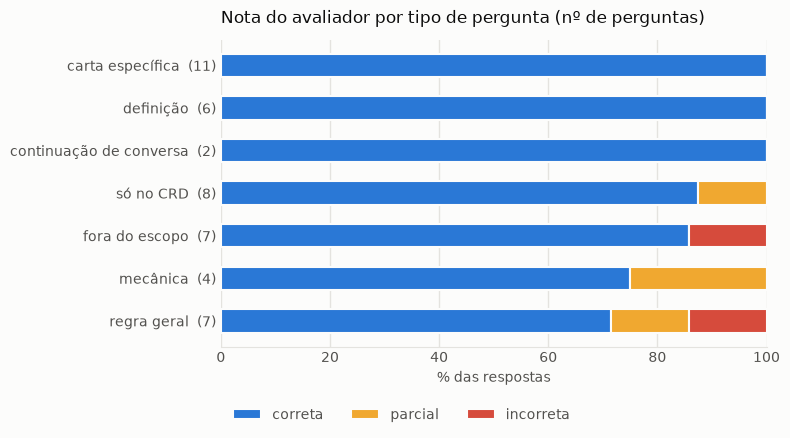

In [4]:
COR_CORRETA, COR_PARCIAL, COR_INCORRETA = "#2a78d6", "#f0a830", "#d64b3c"
COR_TEXTO, COR_TEXTO_2, COR_GRADE, COR_FUNDO = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"


def estilo_eixo(ax, titulo, rotulo_x):
    ax.set_facecolor(COR_FUNDO)
    ax.set_title(titulo, loc="left", color=COR_TEXTO, fontsize=12, pad=12)
    ax.set_xlabel(rotulo_x, color=COR_TEXTO_2)
    ax.tick_params(colors=COR_TEXTO_2, length=0)
    ax.xaxis.grid(True, color=COR_GRADE, linewidth=1)
    ax.set_axisbelow(True)
    for lado in ["top", "right", "left"]:
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(COR_GRADE)


dados = por_cat.sort_values(["correta", "perguntas"])
rotulos = [f"{nome}  ({n:.0f})" for nome, n in zip(dados.index, dados.perguntas)]
fig, ax = plt.subplots(figsize=(8, 0.45 * len(dados) + 1.4), facecolor=COR_FUNDO)
esquerda = pd.Series(0.0, index=dados.index)
for nota, cor in [("correta", COR_CORRETA), ("parcial", COR_PARCIAL), ("incorreta", COR_INCORRETA)]:
    ax.barh(rotulos, dados[nota] * 100, left=esquerda * 100, height=0.55, color=cor, label=nota,
            edgecolor=COR_FUNDO, linewidth=1.5)
    esquerda += dados[nota]
ax.set_xlim(0, 100)
ax.legend(ncols=3, loc="upper left", bbox_to_anchor=(0, -0.16), frameon=False, labelcolor=COR_TEXTO_2)
estilo_eixo(ax, "Nota do avaliador por tipo de pergunta (nº de perguntas)", "% das respostas")
plt.tight_layout()
plt.show()

Os tipos em que o juiz vai **perfeito** são os que dependem de achar **um texto específico**: carta, definição e continuação. Os erros se concentram em **regra geral** e **mecânica**, justamente as perguntas sobre *timing* (quem pode responder e quando), que também foram as mais difíceis pra busca no notebook 02.

O jeito de perguntar quase não mudou o resultado. O avaliador deu "correta" em 86% das formais, 92% das informais e 86% das que usam termos em português ("Emboscada"). As 9 perguntas **reais** (tiradas do uso do app) tiveram 100%.

## 3. Onde o juiz erra

In [5]:
problemas = df[(df.nota != "correta") | (df.conclusao_certa == False)]
tabela = problemas[["id", "categoria", "pergunta", "conclusao_esperada", "conclusao_da_resposta", "nota", "justificativa"]]
with pd.option_context("display.max_colwidth", 140):
    display(tabela.set_index("id"))

,categoria,pergunta,conclusao_esperada,conclusao_da_resposta,nota,justificativa
id,,,,,,
q05,carta,O Guardian Angel salva minha unidade do Smite?,depende,sim,correta,"A resposta do juiz chega à mesma conclusão da esperada, explicando corretamente a interação dos efeitos de substituição."
q13,regra_geral,"Se eu matar a unidade depois que a habilidade desencadeada dela foi pro chain, a habilidade ainda resolve?",sim,sim,parcial,"A conclusão principal está certa, mas o juiz introduziu uma confusão sobre a habilidade matar a unidade que a originou."
q15,regra_geral,Dá pra responder quando o oponente baixa uma unidade?,não,sim,incorreta,A resposta do juiz afirma incorretamente que é possível responder antes da unidade entrar no tabuleiro.
q20,mecanica,Posso usar Emboscada pra jogar uma unidade na minha base?,não,sim,parcial,"A resposta do juiz cria confusão ao iniciar com 'Sim' para a pergunta sobre o uso de Emboscada na base, embora depois explique corretame..."
q22,so_crd,Quantas cartas precisa ter o deck principal e quantas cópias da mesma carta posso colocar?,None,sim,parcial,"A resposta do juiz chega $$$$ conclus''''o correta sobre o deck principal e limite de cópias, mas deixa de mencionar a Champion Legend e..."
q34,so_crd,"se eu jogo uma spell, meu oponente passa, eu tenho que passar tambem pra resolver a chain?",não,depende,correta,"O juiz explicou corretamente que o jogo resolve a magia automaticamente após a passagem do oponente, chegando à mesma conclusão da respo..."
q44,fora_do_escopo,Como eu monto um deck bom de Jinx?,None,depende,incorreta,A resposta do juiz tentou dar dicas de estratégia e montagem de deck em vez de informar que isso não é coberto pelas regras oficiais.


Lendo as respostas, aparecem **três padrões**:

1. **A primeira palavra contradiz o resto.** O prompt pede pra começar com Sim / Não / Depende, e o Flash-Lite às vezes escolhe a palavra errada, mesmo quando a explicação está certa:
   - **q20:** "Posso usar Emboscada pra jogar uma unidade na base?" → "**Sim.** Você pode jogar a unidade na base, mas com o timing normal." A resposta certa é **Não**: o Ambush não vale na base.
   - **q05:** abriu com "Sim" onde o certo é "Depende".
   - **q22:** abriu com "Sim." numa pergunta de "quantas cartas".
2. ***Timing* da Chain e da prioridade** (q15, q34). São as regras mais abstratas do jogo:
   - **q15:** disse que dá pra reagir a uma unidade sendo jogada. O FAQ diz o contrário: a unidade resolve na hora e entra no tabuleiro antes de alguém poder reagir (CRD 337.2).
   - **q34:** disse que a Chain resolve "não porque os dois passaram", mas é exatamente por isso (CRD 339.1).
3. **Pergunta de estratégia** (q44, "como monto um deck bom de Jinx?"). O gabarito esperava "não encontrei". O juiz respondeu com as regras de construção de deck, que estão certas (CRD 103), e deu uma dica leve de estratégia.

## 4. "Não encontrei" e citações inventadas

Estes são os dois comportamentos que mais importam num juiz: **não inventar**.

In [6]:
fora = df[df.categoria == "fora_do_escopo"]
com_resposta = df[df.categoria != "fora_do_escopo"]
print(f"Fora do escopo: disse 'não encontrei' em {(~fora.encontrou).sum()} de {len(fora)}")
print(f"Com resposta:   disse 'não encontrei' por engano em {(~com_resposta.encontrou).sum()} de {len(com_resposta)}")
print(f"Regras citadas que não existem no CRD: {df.regras_inventadas.str.len().sum()}")
print(f"Fontes [Fn] citadas que não foram entregues ao LLM: {df.fontes_inexistentes.str.len().sum()}")
fora[["id", "pergunta", "encontrou"]].set_index("id")

Fora do escopo: disse 'não encontrei' em 6 de 7
Com resposta:   disse 'não encontrei' por engano em 0 de 38
Regras citadas que não existem no CRD: 0
Fontes [Fn] citadas que não foram entregues ao LLM: 0


,pergunta,encontrou
id,,
q25,Qual é o melhor deck do meta agora?,False
q26,Quanto custa uma caixa de booster de Origins?,False
q27,"O que faz a carta Singed, Alquimista Louco?",False
q28,"No Magic: The Gathering, como funciona o mana ...",False
q43,Quando sai a próxima coleção de Riftbound?,False
q44,Como eu monto um deck bom de Jinx?,True
q45,"No Legends of Runeterra, como funciona o Últim...",False


- **Zero citações inventadas** em 45 respostas: nenhuma regra fora do CRD e nenhuma fonte fantasma. Esse é o principal ganho do RAG: o LLM cita o que recebeu, e o que ele cita dá pra conferir.
- **Nenhum "não encontrei" por engano** nas 38 perguntas com resposta.
- Nas perguntas **fora do escopo**, recusou meta, preço, carta inexistente, data de lançamento e perguntas de **outros jogos** (Magic e LoR). Esta última é a instrução nova da etapa 7. A exceção é a q44 (estratégia), comentada acima.

## 5. Dá pra confiar no avaliador automático?

O avaliador (Gemini 3.5 Flash-Lite) deu nota às 45 respostas. Pra saber se essa nota vale alguma coisa, **12 respostas foram revisadas por uma pessoa, às cegas** (sem ver a nota do avaliador). A amostra foi escolhida de propósito com **mais casos difíceis**: todos em que o avaliador não deu "correta" ou a conclusão não bateu, mais um caso fácil de cada categoria. Isso deixa a comparação mais exigente do que seria numa amostra aleatória.

Três medidas de concordância:

| Medida | O que é |
|---|---|
| **concordância exata** | % de respostas em que os dois deram a mesma nota |
| **kappa de Cohen** | a concordância **descontando a que aconteceria por sorte**: 1 = perfeita, 0 = igual ao acaso |
| **correta ou não** | versão simplificada: os dois concordam se a resposta está "correta" ou tem algum problema? |

In [7]:
c = concordancia(ROTULO)
print(f"{c['respostas']} respostas revisadas")
print(f"concordância exata: {c['concordancia_exata']:.0%}")
print(f"kappa de Cohen:     {c['kappa']:.2f}")
print(f"correta ou não:     {c['concordancia_correta_ou_nao']:.0%}")
print(f"avaliador mais severo que o humano em: {', '.join(c['avaliador_mais_severo'])}")
print(f"avaliador mais brando que o humano em: {', '.join(c['avaliador_mais_brando'])}")

12 respostas revisadas
concordância exata: 50%
kappa de Cohen:     -0.06
correta ou não:     58%
avaliador mais severo que o humano em: q15, q13, q20, q44, q22
avaliador mais brando que o humano em: q34


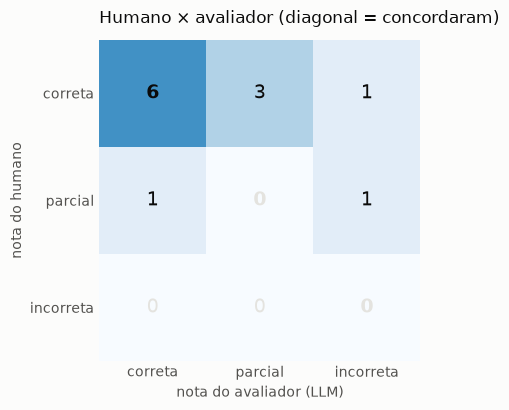

In [8]:
matriz = c["matriz"]
fig, ax = plt.subplots(figsize=(5.2, 4.2), facecolor=COR_FUNDO)
ax.imshow(matriz.values, cmap="Blues", vmin=0, vmax=matriz.values.max() * 1.6)
for i in range(3):
    for j in range(3):
        valor = matriz.values[i, j]
        ax.text(j, i, str(valor), ha="center", va="center", fontsize=14,
                color=COR_TEXTO if valor else COR_GRADE, fontweight="bold" if i == j else "normal")
ax.set_xticks(range(3), matriz.columns)
ax.set_yticks(range(3), matriz.index)
ax.set_xlabel("nota do avaliador (LLM)", color=COR_TEXTO_2)
ax.set_ylabel("nota do humano", color=COR_TEXTO_2)
ax.tick_params(colors=COR_TEXTO_2, length=0)
ax.set_title("Humano × avaliador (diagonal = concordaram)", loc="left", color=COR_TEXTO, fontsize=12, pad=12)
for lado in ax.spines.values():
    lado.set_visible(False)
plt.tight_layout()
plt.show()

### Como ler esses números

- **Concordaram em 6 de 12.** Todas as 6 são respostas que os dois acharam corretas.
- **O kappa ficou perto de zero**, o que parece dizer "tanto faz, é sorteio". Mas o kappa engana em amostras **pequenas** e **desequilibradas**: o humano deu "correta" em 10 de 12, então só por sorte os dois já concordariam em ~53% das vezes. Com 12 respostas, uma única nota diferente muda muito o kappa. Aqui vale mais olhar **caso a caso**.

### Terceira leitura: o que diz a fonte em cada divergência

Quando dois avaliadores discordam, o procedimento comum é um **desempate** com o texto de referência. Pra cada divergência, o texto do FAQ/CRD:

| | humano | avaliador | o que a fonte diz | mais perto da fonte |
|---|---|---|---|---|
| **q13** | correta | parcial | A habilidade resolve mesmo sem a fonte (FAQ *abilities#source-removal*). O juiz acertou isso, mas se confundiu ao dizer que "a instrução de matá-la é ignorada", como se a habilidade matasse a própria unidade | avaliador |
| **q15** | parcial | incorreta | "You cannot react to another player's unit before it enters the board" (FAQ *chain-and-priority*). O juiz abriu com **Sim**, o contrário | avaliador |
| **q20** | correta | parcial | O Ambush só vale pra battlefield (FAQ *ambush*). A pergunta era sobre usar Emboscada na base, e o juiz abriu com **Sim** | avaliador |
| **q22** | correta | parcial | 40 cartas e 3 cópias estão certos, e o Unique existe (CRD 825.3.a). O avaliador cobrou Champion Legend e Rune Deck, **que a pergunta não pediu** | humano |
| **q34** | parcial | correta | A Chain resolve **porque** todos passaram em sequência (CRD 339.1), e quem jogou a spell recebe a prioridade primeiro (CRD 337.4). O juiz disse o contrário | humano |
| **q44** | correta | incorreta | O gabarito pede "não encontrei". O juiz deu regras de construção corretas (CRD 103) e uma dica leve de estratégia | depende do gabarito |

### Conclusão sobre o avaliador

- **Quando o avaliador diz "correta", é confiável:** o humano concordou em 6 de 7. A exceção (q34) é um erro sutil de *timing*.
- **Quando ele aponta um problema, vale conferir:** dos 5 casos, 3 eram problemas reais (q13, q15, q20). Os outros foram exigência demais (q22) e uma questão de gabarito (q44).
- Ele erra nos dois sentidos, e não "sempre mais severo": é **rígido com detalhes que a pergunta não pediu** e **deixa passar erros sutis de regra**.
- Numa justificativa (q22) o Flash-Lite escreveu texto corrompido ("chega $$$$ conclus''''o"). É um sinal de que o modelo mais barato tem limites como avaliador.
- **Uso recomendado:** o avaliador funciona como **filtro**, pra decidir o que uma pessoa precisa ler, e não como juiz final. Os números "89% correta" devem ser lidos com essa ressalva. As métricas automáticas (conclusão, citações) são as mais confiáveis.

A métrica automática de conclusão, que só compara a 1ª palavra, pegou **q15, q20 e q34**, três dos erros reais. Ela é simples, mas pegou erros que passaram por um dos revisores.

## 6. O corte do "não encontrei" (e5-small)

Se a similaridade do 1º resultado da busca ficar abaixo do corte (0,78 no e5-small), o juiz responde "não encontrei" **sem chamar o LLM**. Isso economiza cota e evita respostas inventadas. Mas o corte ajudou nesta rodada?

                  min  median    max
grupo                               
com resposta    0.819   0.853  0.903
fora do escopo  0.782   0.809  0.846


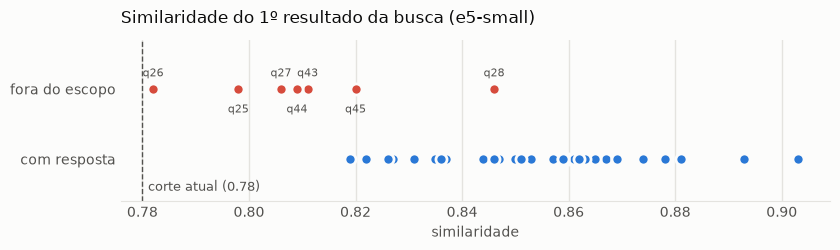

In [9]:
CORTE = config.LIMIAR_NAO_ENCONTREI["e5-small"]
df["grupo"] = df.categoria.map(lambda c: "fora do escopo" if c == "fora_do_escopo" else "com resposta")
print(df.groupby("grupo").nota_busca.agg(["min", "median", "max"]).round(3).to_string())

fig, ax = plt.subplots(figsize=(8.5, 2.6), facecolor=COR_FUNDO)
for y, (grupo, cor) in enumerate([("com resposta", COR_CORRETA), ("fora do escopo", COR_INCORRETA)]):
    sub = df[df.grupo == grupo]
    ax.scatter(sub.nota_busca, [y] * len(sub), s=64, color=cor, edgecolors=COR_FUNDO, linewidths=2, zorder=3)
    if grupo == "fora do escopo":
        sub = sub.sort_values("nota_busca")
        for k, (x, rotulo) in enumerate(zip(sub.nota_busca, sub.id)):  # alterna em cima/embaixo pra não sobrepor
            ax.annotate(rotulo, (x, y), xytext=(0, 9 if k % 2 == 0 else -17), textcoords="offset points",
                        ha="center", fontsize=8, color=COR_TEXTO_2)
ax.axvline(CORTE, color=COR_TEXTO_2, linestyle="--", linewidth=1)
ax.annotate(f"corte atual ({CORTE})", (CORTE, -0.45), xytext=(4, 0), textcoords="offset points", fontsize=9, color=COR_TEXTO_2)
ax.set_yticks([0, 1], ["com resposta", "fora do escopo"])
ax.set_ylim(-0.6, 1.7)
estilo_eixo(ax, "Similaridade do 1º resultado da busca (e5-small)", "similaridade")
plt.tight_layout()
plt.show()

- **As duas faixas se sobrepõem:**
  - fora do escopo: 0,78 a 0,85;
  - com resposta: 0,82 a 0,90.

  A q28 (Magic) tem nota **maior** que várias perguntas legítimas, porque "mana", "custo" e "carta" aparecem nas regras de qualquer jogo de cartas.
- **O corte de 0,78 não barrou nenhuma pergunta.** Quem disse "não encontrei" nas 6 recusas foi o LLM, seguindo as instruções.
- Subir o corte pra ~0,81 barraria 4 das 7 perguntas fora do escopo e nenhuma legítima **nesta amostra**. Mas a folga até a pergunta legítima mais baixa (q32, 0,819) é de menos de 0,01. Com 45 perguntas, é arriscado demais: uma pergunta real um pouco diferente seria recusada sem nem passar pelo LLM.
- **Decisão: manter 0,78.** O corte fica como rede de segurança pra perguntas totalmente sem relação, e a recusa fina fica com o LLM. O corte do Gemini (0,60) é conferido na rodada com a cota cheia.

## 7. Os ajustes e a nova rodada

Com esse diagnóstico, foram feitos **4 ajustes**:

1. **Prompt: a 1ª palavra responde exatamente o que foi perguntado.**
   - Sim / Não / Depende só aparece em pergunta de sim ou não. "Quantas cartas...?" começa direto pela resposta.
   - Se uma fonte diz que algo *cannot* acontecer no caso perguntado, a resposta não pode começar com "Sim".
   - O exemplo no prompt é **genérico** ("posso usar X pra fazer Y?") e não uma pergunta do gabarito. Colocar o próprio gabarito no prompt seria estudar pra prova com a resposta na mão: o número melhoraria sem o juiz melhorar.
2. **Definições oficiais do *timing*** em `juiz/definicoes.yaml`:
   - **Priority** ganhou a regra 312.2 (quando cada jogador recebe a prioridade);
   - **Pass** é novo, com as regras 337.4, 338.1.b.1, 339.1, 339.2 e 340.1 (quem recebe a prioridade depois de jogar algo, e por que a Chain resolve);
   - **Finalize** ganhou as regras 337.1.a e 337.2 (finalizar não passa a prioridade; Unit e Gear resolvem na hora);
   - no glossário, "passar", "passa" etc. viram **Pass**.
3. **Avaliador:** julgar só o que a **pergunta** pede, sem cobrar detalhes extras da resposta esperada.
4. **Gabarito da q44:** aceita as regras de construção de deck, desde que o juiz diga antes que estratégia não está nas regras. O prompt ganhou a regra correspondente: pergunta de estratégia, meta ou preço começa com "não encontrei" e pode resumir as regras ligadas ao assunto.

Na nova rodada apareceu também um **bug na própria métrica**:
- a leitura da conclusão pegava a 1ª palavra separando só por espaço, então "Não.\n\nDurante..." não era lido como "não";
- "Não encontrei" era lido como a conclusão "não".

Os dois casos foram corrigidos, e a conclusão agora é sempre recalculada a partir do texto.

A nova rodada usa a mesma configuração (e5-small + Flash-Lite, as 45 perguntas) e fica em `respostas_flash-lite_e5_v2.jsonl`.

In [10]:
DEPOIS = "flash-lite_e5_v2"
v2 = pd.read_json(config.RESULTADOS_DIR / f"respostas_{DEPOIS}.jsonl", lines=True)
v2["conclusao_esperada"] = [gabarito[i].get("conclusao") for i in v2.id]
v2["conclusao_da_resposta"] = v2.resposta.map(conclusao_da_resposta)
v2["conclusao_certa"] = [conclusao_confere(gabarito[i].get("conclusao"), c) for i, c in zip(v2.id, v2.conclusao_da_resposta)]
v2["citacao_inventada"] = (v2.regras_inventadas.str.len() + v2.fontes_inexistentes.str.len()) > 0


def metricas(d):
    com_resposta = d[d.categoria != "fora_do_escopo"]
    return pd.Series({
        "conclusão (Sim/Não/Depende) certa": pct(d.conclusao_certa),
        "citou uma fonte certa": pct(d.citou_fonte_certa),
        "'não encontrei' por engano": pct(~com_resposta.encontrou),
        "recusou as fora do escopo": pct(~d[d.categoria == "fora_do_escopo"].encontrou),
        "respostas com citação inventada": pct(d.citacao_inventada),
        "avaliador: correta": pct(d.nota == "correta"),
        "avaliador: incorreta": pct(d.nota == "incorreta"),
        "tempo por resposta (mediana)": f"{d.segundos.median():.1f} s",
        "tokens enviados ao LLM (média)": f"{d.tokens_entrada.mean():,.0f}".replace(",", "."),
    })


pd.DataFrame({"antes (rodada 1)": metricas(df), "depois (rodada 2)": metricas(v2)})

,antes (rodada 1),depois (rodada 2)
conclusão (Sim/Não/Depende) certa,81% (17 de 21),95% (20 de 21)
citou uma fonte certa,97% (37 de 38),95% (36 de 38)
'não encontrei' por engano,0% (0 de 38),3% (1 de 38)
recusou as fora do escopo,86% (6 de 7),100% (7 de 7)
respostas com citação inventada,0% (0 de 45),0% (0 de 45)
avaliador: correta,89% (40 de 45),93% (42 de 45)
avaliador: incorreta,4% (2 de 45),2% (1 de 45)
tempo por resposta (mediana),1.6 s,3.0 s
tokens enviados ao LLM (média),4.309,4.689


Os ajustes 3 e 4 mudam o **instrumento de medida** (avaliador e gabarito), e não o juiz. Por isso, a comparação mais limpa é a das **métricas automáticas**. A nota do avaliador mistura as duas coisas: o juiz mudou e o avaliador também.

**O custo:** o contexto ficou ~9% maior (as definições novas). O tempo mediano subiu de 1,6 s pra 3,0 s, mas o tempo depende muito da carga da API na hora, e as duas rodadas foram feitas em horários diferentes.

**Pergunta por pergunta**, onde algo mudou:

In [11]:
colunas = ["conclusao_da_resposta", "nota", "encontrou"]
lado_a_lado = df.set_index("id")[["pergunta", "conclusao_esperada"] + colunas].join(
    v2.set_index("id")[colunas], rsuffix=" (depois)")
mudou = pd.Series(False, index=lado_a_lado.index)
for c in colunas:
    mudou |= lado_a_lado[c].fillna("—").astype(str) != lado_a_lado[f"{c} (depois)"].fillna("—").astype(str)
lado_a_lado[mudou].fillna("—")

,pergunta,conclusao_esperada,conclusao_da_resposta,nota,encontrou,conclusao_da_resposta (depois),nota (depois),encontrou (depois)
id,,,,,,,,
q05,O Guardian Angel salva minha unidade do Smite?,depende,sim,correta,True,depende,correta,True
q07,Por quanto tempo o Endless Riches me faz pular...,—,depende,correta,True,sim,correta,True
q13,Se eu matar a unidade depois que a habilidade ...,sim,sim,parcial,True,sim,correta,True
q15,Dá pra responder quando o oponente baixa uma u...,não,sim,incorreta,True,—,incorreta,False
q19,Pra onde vai um feitiço jogado com Flow se ele...,—,sim,correta,True,—,correta,True
q20,Posso usar Emboscada pra jogar uma unidade na ...,não,sim,parcial,True,não,correta,True
q21,O que acontece com o equipamento quando a unid...,—,sim,correta,True,—,correta,True
q22,Quantas cartas precisa ter o deck principal e ...,—,sim,parcial,True,—,correta,True
q23,Quantos pontos preciso pra ganhar?,—,sim,correta,True,—,correta,True


- **Corrigidas:**
  - **q20** (Emboscada na base) abre com "Não";
  - **q05** abre com "Depende";
  - **q22** ("quantas cartas...?") começa direto pela resposta, sem o "Sim." solto;
  - **q44** diz que estratégia não está nas regras e resume as regras de construção.
- **q34** abre com "Não", como deveria. O avaliador, agora mais atento, deu "parcial": a explicação ainda não diz que quem jogou a spell recebe a prioridade primeiro.
- **q15 piorou de um jeito diferente:** em vez do "Sim" errado, disse "não encontrei". A busca e5-small não traz a página certa do FAQ (a do Gemini traz, em 1º lugar), e o Flash-Lite preferiu não responder.
- **q29** caiu pra "parcial" no avaliador, com uma resposta diferente da primeira rodada.

Antes de comemorar, falta uma pergunta: **esses números são estáveis?**

### Uma rodada só engana

O LLM não responde sempre igual à mesma pergunta: há um sorteio em cada palavra gerada. Pra medir isso, as 4 perguntas-problema foram feitas mais 3 vezes, com o prompt novo. Somando a rodada 2, são 4 execuções de cada:

| | conclusão esperada | 4 execuções depois dos ajustes | acertos |
|---|---|---|---|
| **q20** Emboscada na base | não | Não · Não · Não · Não | **4 de 4** |
| **q15** responder a uma unidade | não | Não encontrei · Não · Não · Sim | 2 de 4 |
| **q05** Guardian Angel × Smite | depende | Depende · Sim · Depende · Sim | 2 de 4 |
| **q34** passar pra resolver a Chain | não | Não · Depende · Depende · Depende | 1 de 4 |

O que isso mostra:
- **q20 foi corrigida de verdade.**
- **q15, q05 e q34 oscilam.** A rodada 2 pegou o lado bom delas por sorte. Antes dos ajustes, elas erraram numa execução só, então também não dá pra afirmar que "sempre erravam".
- **Consequência pra métrica:** "conclusão certa" com uma execução só tem uma margem de erro grande. Os 95% da rodada 2 exageram a melhora; o ganho real está em algum ponto entre os 81% e os 95%. Pra medir direito, cada pergunta teria que ser feita várias vezes, e a métrica seria a **taxa de acerto por pergunta**.
- Na q05, "Sim" também é defensável: o Guardian Angel **pode** salvar a unidade, se você escolher a ordem. Tanto você quanto o avaliador deram "correta" pra resposta com "Sim". O gabarito poderia aceitar ["sim", "depende"], como já faz na q29.

### O avaliador depois do ajuste

As **mesmas 12 respostas** da revisão humana (da rodada 1) receberam nota de novo, com as instruções novas do avaliador e o gabarito novo da q44. Como a resposta é a mesma, o que muda é só o avaliador.

In [12]:
reav = pd.read_csv(config.RESULTADOS_DIR / "concordancia_avaliador_v2.csv")
h = reav.humano.tolist()
resumo_conc = pd.DataFrame({
    col: {"concordância exata": f"{(reav.humano == reav[col]).mean():.0%}",
          "correta ou não": f"{((reav.humano == 'correta') == (reav[col] == 'correta')).mean():.0%}",
          "kappa": f"{kappa_de_cohen(h, reav[col].tolist(), NOTAS):.2f}"}
    for col in ["antes", "depois"]})
display(resumo_conc)
reav[reav.antes != reav.depois][["id", "humano", "antes", "depois", "justificativa"]].set_index("id")

,antes,depois
concordância exata,50%,67%
correta ou não,58%,75%
kappa,-0.06,0.04


,humano,antes,depois,justificativa
id,,,,
q13,correta,parcial,correta,A resposta do juiz chega $mesma conclus$o da e...
q44,correta,incorreta,parcial,O juiz deu dicas de estratégia ao sugerir cart...
q22,correta,parcial,correta,A resposta do juiz aborda corretamente o taman...


- **q22** virou "correta", o efeito esperado: a pergunta não pedia Champion Legend nem Rune Deck.
- **q44** foi de "incorreta" pra "parcial". Com o gabarito novo, responder as regras de construção é aceito, mas a resposta antiga dava uma dica de estratégia ("cartas que funcionem com descarte"), que o gabarito novo não aceita.
- **q13** também virou "correta". Aqui a concordância com o humano subiu, mas pela leitura da fonte (seção 5) "parcial" estava mais perto do certo. **Concordar mais com o humano não é o mesmo que acertar mais**, principalmente quando o humano também é iniciante no jogo.
- A concordância subiu de 50% pra 67%. Com 12 respostas, cada uma vale 8 pontos percentuais, então é uma melhora modesta e pouco precisa.
- O texto corrompido na justificativa apareceu de novo (q13: "chega $mesma conclus$o"). É um limite do Flash-Lite como avaliador.

## 8. Modelo principal × reserva

O juiz usa o **Gemini 3.8 Flash** quando há cota. A comparação usa as 18 perguntas de `config.IDS_COMPARACAO`, porque o 3.8 Flash só tem 20 respostas grátis por dia.

In [13]:
PRINCIPAL = "gemini-3.8-flash"
arquivo_principal = config.RESULTADOS_DIR / f"respostas_{PRINCIPAL}.jsonl"
if not arquivo_principal.exists():
    print(f"Pendente: falta rodar `python -m juiz.avaliar_respostas --modelo {PRINCIPAL} --comparacao` (cota do dia).")
else:
    principal = pd.read_json(arquivo_principal, lines=True)
    principal["conclusao_da_resposta"] = principal.resposta.map(conclusao_da_resposta)
    principal["conclusao_certa"] = [conclusao_confere(gabarito[i].get("conclusao"), c)
                                    for i, c in zip(principal.id, principal.conclusao_da_resposta)]
    reserva = v2[v2.id.isin(principal.id)]
    comparacao = pd.DataFrame({"reserva (Flash-Lite + e5)": metricas(reserva), f"principal ({PRINCIPAL})": metricas(principal)})
    display(comparacao)

Pendente: falta rodar `python -m juiz.avaliar_respostas --modelo gemini-3.8-flash --comparacao` (cota do dia).


## Conclusão

**No pior caso (as duas reservas), o juiz já é útil e, principalmente, honesto:**

| | rodada 1 | rodada 2 (com os ajustes) |
|---|---|---|
| conclusão certa nas perguntas de sim/não | 81% (17 de 21) | 95% (20 de 21)\* |
| citou a fonte certa | 97% | 95% |
| citações inventadas | **0** | **0** |
| "não encontrei" por engano | 0 de 38 | 1 de 38 (q15) |
| respostas corretas (avaliador) | 89% | 93%\*\* |

\* Uma execução só. Repetindo as perguntas difíceis, três delas oscilam (seção 7), então a melhora real é menor.
\*\* O avaliador também mudou entre as rodadas.

**O que a avaliação ensinou:**

1. **O erro mais comum era a 1ª palavra**, não o conteúdo. O ajuste no prompt resolveu de forma estável o caso mais claro (q20: 4 de 4) e o formato das perguntas que não são de sim ou não (q22).
2. ***Timing* da Chain e da prioridade continua sendo o ponto fraco** do Flash-Lite. Mesmo com as regras certas no contexto (337.4, 339.1), ele ainda oscila na q34 e na q15. Com a busca Gemini, a fonte certa da q15 vem em 1º lugar; a comparação com o 3.8 Flash vai mostrar quanto disso é limite do modelo mais barato.
3. **Avaliar LLM exige repetição.** Com uma execução por pergunta, a variação do próprio modelo pode parecer melhora ou piora. Pra decisões importantes, vale fazer cada pergunta várias vezes.
4. **O avaliador LLM serve como filtro, não como juiz final.** Ele ficou mais alinhado depois do ajuste (67% de concordância), mas ainda erra nos dois sentidos e às vezes corrompe o texto.
5. **O corte do "não encontrei" não separa bem** no e5-small. A recusa depende das instruções do LLM, e elas funcionaram em todas as perguntas fora do escopo na rodada 2.

**Pendente (depende da cota do dia):** a comparação com o 3.8 Flash (seção 8) e o corte da busca Gemini.